In [117]:
import os

import numpy
import pandas

import matplotlib.pyplot

### Part 1. Parse Open Targets data

#### Drug warning

In [102]:
drug_warning = pandas.read_parquet("data/drug_warning/part-00000-ede10c94-333d-44c9-a6e6-df821957a172-c000.snappy.parquet")
print(f"number of entries: {len(drug_warning)}")
drug_warning.head()

number of entries: 2302


,chemblIds,toxicityClass,country,description,id,references,warningType,year,efo_term,efo_id,efo_id_for_warning_class
0,"[CHEMBL4303288, CHEMBL1380]",hepatotoxicity,United States,None,1,[{'ref_id': 'de109a2b-e36c-40d0-85fc-a67a9e7f1...,Black Box Warning,NaN,None,None,EFO:0011052
1,"[CHEMBL4303288, CHEMBL1380]",metabolic toxicity,United States,None,2,[{'ref_id': 'de109a2b-e36c-40d0-85fc-a67a9e7f1...,Black Box Warning,NaN,None,None,EFO:0011054
2,"[CHEMBL4303288, CHEMBL1380]",immune system toxicity,United States,None,3,[{'ref_id': 'de109a2b-e36c-40d0-85fc-a67a9e7f1...,Black Box Warning,NaN,None,None,EFO:0011053
3,[CHEMBL3301581],carcinogenicity,United States,None,4,[{'ref_id': '712143d9-e21e-4013-bb3b-3426a2106...,Black Box Warning,NaN,None,None,EFO:0011046
4,[CHEMBL1252],None,United States,None,5,[],Black Box Warning,NaN,None,None,None


#### Drug molecule (Drug/Clinical candidates)

In [50]:
drug_molecule = pandas.read_parquet("data/drug_molecule/part-00000-871f412e-aec4-4d33-a50d-feee532ddcd2-c000.snappy.parquet")
print(f"number of drugs: {len(drug_molecule)}")
drug_molecule.head()

number of drugs: 18475


,id,canonicalSmiles,inchiKey,drugType,blackBoxWarning,name,yearOfFirstApproval,maximumClinicalTrialPhase,parentId,hasBeenWithdrawn,isApproved,tradeNames,synonyms,crossReferences,childChemblIds,linkedDiseases,linkedTargets,description
0,CHEMBL1000,O=C(O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1,ZKLPARSLTMPFCP-UHFFFAOYSA-N,Small molecule,False,CETIRIZINE,1995.0,4.0,None,False,True,[],"[AC-170, Cetiderm, Cetirizina, Cetirizine]","[{'source': 'drugbank', 'ids': ['DB00341']}]","[CHEMBL1201113, CHEMBL1607273]","{'rows': ['EFO_0008521', 'HP_0000989', 'EFO_00...","{'rows': ['ENSG00000196639'], 'count': 1}",Small molecule drug with a maximum clinical tr...
1,CHEMBL100014,CCCC(=O)OCOC(=O)C(C)(C)C,GYKLFBYWXZYSOW-UHFFFAOYSA-N,Small molecule,False,AN-9,NaN,2.0,None,False,False,[],"[An-9, Butyric acid 2,2-dimethyl-propionyloxym...","[{'source': 'drugbank', 'ids': ['DB05103']}]",None,"{'rows': ['EFO_0003060', 'EFO_0000095', 'EFO_0...",None,Small molecule drug with a maximum clinical tr...
2,CHEMBL100109,CC(=O)N[C@H](Cc1ccccc1)C(=O)N1CCC[C@H]1C(=O)N[...,UCQIHCRMWNRFNP-QYZOEREBSA-N,Small molecule,False,CHEMBL100109,NaN,NaN,None,False,None,[],[],"[{'source': 'drugbank', 'ids': ['DB07658']}]",[CHEMBL3038261],None,None,Small molecule drug.
3,CHEMBL100116,CC(C)=CCN1CCC2(C)c3cc(O)ccc3CC1C2C,VOKSWYLNZZRQPF-UHFFFAOYSA-N,Small molecule,True,PENTAZOCINE,1967.0,4.0,None,False,True,[],"[Dl-pentazocine, NIH-7958, NSC-107430, Pentazo...",None,"[CHEMBL5483020, CHEMBL3989509, CHEMBL3989510]","{'rows': ['MONDO_0004985', 'HP_0012531', 'HP_0...","{'rows': ['ENSG00000147955'], 'count': 1}",Small molecule drug with a maximum clinical tr...
4,CHEMBL1002,CC(C)(C)NC[C@H](O)c1ccc(O)c(CO)c1,NDAUXUAQIAJITI-LBPRGKRZSA-N,Small molecule,True,LEVOSALBUTAMOL,1999.0,4.0,None,False,True,[],"[ASF-1096, Albuterol (r)-form, Levalbuterol, L...","[{'source': 'drugbank', 'ids': ['DB13139']}]","[CHEMBL3989693, CHEMBL1201061, CHEMBL3989589]","{'rows': ['MONDO_0004979', 'MONDO_0004979', 'E...","{'rows': ['ENSG00000169252'], 'count': 1}",Small molecule drug with a maximum clinical tr...


#### Target (gene-to-ENSG mapping)

In [60]:
target_parquet_dir = "data/target/"
parquet_files = []
for f in os.listdir(target_parquet_dir):
    if f.endswith(".parquet") or f.endswith(".snappy.parquet"):
        parquet_file = os.path.join(target_parquet_dir, f)
        parquet_files.append(parquet_file)

target = pandas.DataFrame()
for file in parquet_files:
    target = pandas.concat([target, pandas.read_parquet(file)])
target.head()

,id,approvedSymbol,biotype,transcriptIds,canonicalTranscript,canonicalExons,genomicLocation,alternativeGenes,approvedName,go,...,constraint,tep,proteinIds,dbXrefs,chemicalProbes,homologues,tractability,safetyLiabilities,pathways,tss
0,ENSG00000000457,SCYL3,protein_coding,"[ENST00000423670, ENST00000367770, ENST0000036...","{'id': 'ENST00000367771', 'chromosome': '1', '...","[169854270, 169854964, 169868928, 169869039, 1...","{'chromosome': '1', 'start': 169846981, 'end':...",None,SCY1 like pseudokinase 3,"[{'id': 'GO:0042802', 'source': 'GO_REF:000010...",...,"[{'constraintType': 'syn', 'score': 1.07690000...",None,"[{'id': 'Q8IZE3', 'source': 'uniprot_swissprot...","[{'id': '19285', 'source': 'HGNC'}, {'id': 'IP...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,None,169893896.0
1,ENSG00000001167,NFYA,protein_coding,"[ENST00000914458, ENST00000914462, ENST0000091...","{'id': 'ENST00000341376', 'chromosome': '6', '...","[41094396, 41094497, 41091528, 41091694, 41084...","{'chromosome': '6', 'start': 41072946, 'end': ...",None,nuclear transcription factor Y subunit alpha,"[{'id': 'GO:0000785', 'source': 'GO_REF:000011...",...,"[{'constraintType': 'syn', 'score': 0.46832001...",None,"[{'id': 'P23511', 'source': 'uniprot_swissprot...","[{'id': '7804', 'source': 'HGNC'}, {'id': '4AW...",None,"[{'speciesId': '9598', 'speciesName': 'Chimpan...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,"[{'pathwayId': 'R-HSA-9614657', 'pathway': 'FO...",41072974.0
2,ENSG00000001460,STPG1,protein_coding,"[ENST00000483528, ENST00000468303, ENST0000043...","{'id': 'ENST00000337248', 'chromosome': '1', '...","[24413674, 24413782, 24369674, 24369839, 24360...","{'chromosome': '1', 'start': 24355886, 'end': ...",None,sperm tail PG-rich repeat containing 1,"[{'id': 'GO:1902110', 'source': 'GO_REF:000003...",...,"[{'constraintType': 'syn', 'score': 0.54615998...",None,"[{'id': 'Q5TH74', 'source': 'uniprot_swissprot...","[{'id': '28070', 'source': 'HGNC'}, {'id': 'IP...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,None,24413782.0
3,ENSG00000001629,ANKIB1,protein_coding,"[ENST00000439883, ENST00000422095, ENST0000092...","{'id': 'ENST00000265742', 'chromosome': '7', '...","[92307359, 92307656, 92294889, 92295166, 92319...","{'chromosome': '7', 'start': 92245973, 'end': ...",None,ankyrin repeat and IBR domain containing 1,"[{'id': 'GO:0008270', 'source': 'GO_REF:000000...",...,"[{'constraintType': 'syn', 'score': 1.35239994...",None,"[{'id': 'Q9P2G1', 'source': 'uniprot_swissprot...","[{'id': '22215', 'source': 'HGNC'}, {'id': 'IP...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,None,92245974.0
4,ENSG00000003096,KLHL13,protein_coding,"[ENST00000881391, ENST00000881390, ENST0000037...","{'id': 'ENST00000540167', 'chromosome': 'X', '...","[117920238, 117920370, 117919521, 117919717, 1...","{'chromosome': 'X', 'start': 117897794, 'end':...",None,kelch like family member 13,"[{'id': 'GO:0005829', 'source': 'Reactome:R-HS...",...,None,None,"[{'id': 'Q9P2N7', 'source': 'uniprot_swissprot...","[{'id': '22931', 'source': 'HGNC'}, {'id': 'R-...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,"[{'pathwayId': 'R-HSA-983168', 'pathway': 'Ant...",118116810.0


In [61]:
# map ENSG to gene names and vice versa
ENSG2gene_name = {}
gene_name2ENSG = {}
for index, row in target.iterrows():
    ENSG = row['id']
    gene = row['approvedSymbol']

    # some entries are incomplete
    if ENSG == gene:
        continue
    if ENSG in ENSG2gene_name:
        assert ENSG2gene_name[ENSG] == gene
    if gene in gene_name2ENSG:
        print(f"{gene} already mapped to {gene_name2ENSG[gene]}, skipping it")
        continue

    ENSG2gene_name[ENSG] = gene
    gene_name2ENSG[gene] = ENSG

assert len(ENSG2gene_name) == len(gene_name2ENSG)

Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipp

### Part 2. Generate a not-working target set

In [76]:
# find withdrawn drugs
withdrawn = []

for index, row in drug_molecule.iterrows():
    if not row['hasBeenWithdrawn']:
        continue
    withdrawn.append(row['id'])

print(f"Found {len(withdrawn)} withdrawn drugs")

Found 308 withdrawn drugs


In [95]:
# filter withdrawn drugs, keep those with linked targets and diseases
withdrawn2targets = {}
withdrawn2diseases = {}

for drug in withdrawn:
    linked_targets = drug_molecule.loc[drug_molecule['id'] == drug, 'linkedTargets'].iloc[0]
    linked_diseases = drug_molecule.loc[drug_molecule['id'] == drug, 'linkedDiseases'].iloc[0]

    # keep only drugs with linked targets
    if (not linked_targets) or (linked_targets['count'] < 1):
        print(f"{drug} has been withdrawn but has no linked targets")
        continue
    targets = linked_targets['rows']  # format: {'rows': ['ENSG00000196639'], 'count': 1}

    # keep only drugs with linked diseases
    if (not linked_diseases) or (linked_diseases['count'] < 1):
        print(f"{drug} has been withdrawn but has no linked diseases")
        continue
    diseases = linked_diseases['rows']  # format: {'rows': ['EFO_0008521', ...}
    if len(diseases) < 1:
        print(f"{drug} has been withdrawn but has no linked diseases")
        continue

    withdrawn2targets[drug] = targets
    withdrawn2diseases[drug] = diseases

print(f"Keeping {len(withdrawn2targets)} withdrawn drugs with linked targets and diseases")

CHEMBL1018 has been withdrawn but has no linked diseases
CHEMBL106258 has been withdrawn but has no linked targets
CHEMBL110691 has been withdrawn but has no linked diseases
CHEMBL1165342 has been withdrawn but has no linked targets
CHEMBL1177 has been withdrawn but has no linked targets
CHEMBL1183717 has been withdrawn but has no linked targets
CHEMBL1184360 has been withdrawn but has no linked targets
CHEMBL1191 has been withdrawn but has no linked targets
CHEMBL1200393 has been withdrawn but has no linked targets
CHEMBL1200498 has been withdrawn but has no linked targets
CHEMBL1200549 has been withdrawn but has no linked diseases
CHEMBL1200563 has been withdrawn but has no linked diseases
CHEMBL1200595 has been withdrawn but has no linked diseases
CHEMBL1200695 has been withdrawn but has no linked diseases
CHEMBL1200714 has been withdrawn but has no linked targets
CHEMBL1200779 has been withdrawn but has no linked targets
CHEMBL1200788 has been withdrawn but has no linked diseases
C

In [100]:
# filter withdrawn drugs, keep those with warnings
drug_warning_list = drug_warning['chemblIds'].explode().to_list()
with_warning_count = 0

withdrawn2targets_copy = withdrawn2targets.copy()
withdrawn2diseases_copy = withdrawn2diseases.copy()

for drug in withdrawn2targets:
    if drug in drug_warning_list:
        with_warning_count += 1
    else:
        del withdrawn2targets_copy[drug]
        del withdrawn2diseases_copy[drug]

withdrawn2targets = withdrawn2targets_copy
withdrawn2diseases = withdrawn2diseases_copy

print(f"Keeping {len(withdrawn2targets)} drugs with warnings")

Keeping 121 drugs with warnings


In [99]:
# find top 10 diseases with most withdrawn drugs
disease2withdrawn_count = {}
for chemblID, diseases in withdrawn2diseases.items():
    for disease in diseases:
        if disease not in disease2withdrawn_count:
            disease2withdrawn_count[disease] = 0
        disease2withdrawn_count[disease] += 1

sorted_disease_withdrawn_count = sorted(disease2withdrawn_count.items(), key=lambda x: x[1], reverse=True)

print("Top 10 diseases with most withdrawn drugs:")
for disease, count in sorted_disease_withdrawn_count[:10]:
    print(f"{disease}: {count} withdrawn drugs")

Top 10 diseases with most withdrawn drugs:
HP_0012531: 28 withdrawn drugs
EFO_0000319: 17 withdrawn drugs
EFO_0001073: 16 withdrawn drugs
EFO_0003890: 14 withdrawn drugs
EFO_0005755: 12 withdrawn drugs
MONDO_0002009: 11 withdrawn drugs
MONDO_0004979: 9 withdrawn drugs
EFO_0000400: 8 withdrawn drugs
MONDO_0005277: 8 withdrawn drugs
MONDO_0005148: 7 withdrawn drugs


### Create profiles of not-working targets

In [138]:
# find toxicity information for withdrawn drugs
toxicity_labels = list(drug_warning['toxicityClass'].unique())

withdrawn2toxicity = {}

drug2toxicity = {}
for index, row in drug_warning.iterrows():
    drugs = row['chemblIds']
    toxicity = row['toxicityClass']
    if not toxicity:
        continue

    for drug in drugs:
        if drug not in drug2toxicity:
            drug2toxicity[drug] = []
        drug2toxicity[drug].append(toxicity)

for drug in withdrawn2targets:
    if drug in drug2toxicity:
        withdrawn2toxicity[drug] = drug2toxicity[drug]

print(f"Found toxicity information for {len(withdrawn2toxicity)} withdrawn drugs")

Found toxicity information for 106 withdrawn drugs


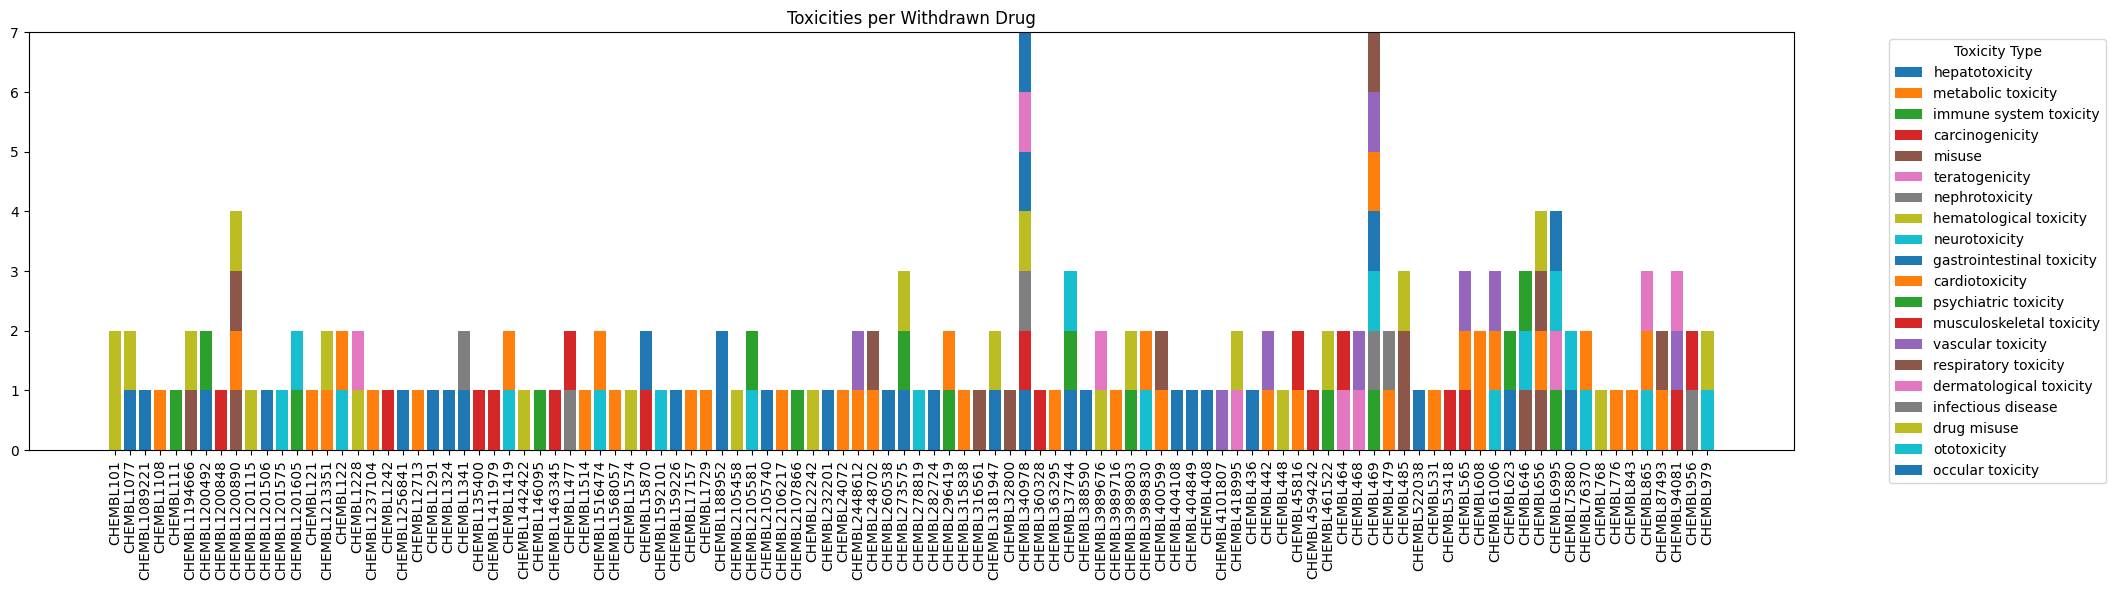

In [154]:
# create stacked bar chart: count of drugs with each toxicity type, each bar segment represents a specific toxicity
drugs = list(withdrawn2toxicity.keys())
matrix = numpy.zeros((len(drugs), len(toxicity_labels)), dtype=int)

# fill binary matrix
for i, drug in enumerate(drugs):
    for tox in withdrawn2toxicity[drug]:
        if tox in toxicity_labels:
            j = toxicity_labels.index(tox)
            matrix[i, j] = 1

# plot stacked bar chart
fig, ax = matplotlib.pyplot.subplots(figsize=(len(drugs)*0.2, 6))

bottom = numpy.zeros(len(drugs))  # keeps track of where to stack

for j, tox in enumerate(toxicity_labels):
    ax.bar(drugs, matrix[:, j], bottom=bottom, label=tox)
    bottom += matrix[:, j]  # update bottom for next stack

ax.set_title('Toxicities per Withdrawn Drug')
ax.legend(title='Toxicity Type', bbox_to_anchor=(1.05, 1), loc='upper left')
matplotlib.pyplot.xticks(rotation=90)
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.savefig("data/withdrawn_toxicity_bar.png", dpi=300)
matplotlib.pyplot.show()

### Save the not-working target set

In [110]:
# save the withdrawn drug-target-disease associations to TSV file
out_file = "data/withdrawn_target_disease.tsv"

with open(out_file, "w") as f:
    f.write("CHEMBLID\tENSGs\tGENE_NAMEs\tEFOs\n")
    for drug in withdrawn2targets:
        ensgs = ",".join(withdrawn2targets[drug])
        gene_names = ",".join([ENSG2gene_name.get(ensg, "N/A") for ensg in withdrawn2targets[drug]])
        efos = ",".join(withdrawn2diseases.get(drug, []))
        f.write(f"{drug}\t{ensgs}\t{gene_names}\t{efos}\n")

In [109]:
# save the not working target-disease associations to TSV file
# each line corresponds to one target gene (ENSG)
out_file = "data/not_working_targets.tsv"

with open(out_file, "w") as f:
    f.write("ENSG\tGENE_NAME\tEFOs\n")
    for drug in withdrawn2diseases:
        for ENSG in withdrawn2targets[drug]:
            gene_name = ENSG2gene_name.get(ENSG, "N/A")
            efos = ",".join(withdrawn2diseases.get(drug, []))
            f.write(f"{ENSG}\t{gene_name}\t{efos}\n")